# SECTION 1. SETUP AND INSTALLATIONS


In [1]:
#IMPORTS
import pandas as pd
import numpy as np
import os
import re
import nltk
nltk.download('stopwords')

from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


# SECTION 2. DATA LOADING AND EXPLORATION

In [2]:
import kagglehub

path = kagglehub.dataset_download("gowrishankarp/newspaper-text-summarization-cnn-dailymail")
inner_path = os.path.join(path, "cnn_dailymail")
print(os.listdir(inner_path))

df = pd.read_csv(os.path.join(inner_path, "train.csv"))
df = df[['article', 'highlights']].dropna()
df = df.sample(5000, random_state=42).reset_index(drop=True)

print(f"Shape: {df.shape}")
df.head(3)

Using Colab cache for faster access to the 'newspaper-text-summarization-cnn-dailymail' dataset.
['validation.csv', 'train.csv', 'test.csv']
Shape: (5000, 2)


,article,highlights
0,By . Mia De Graaf . Britons flocked to beaches...,People enjoyed temperatures of 17C at Brighton...
1,A couple who weighed a combined 32st were sham...,Couple started piling on pounds after the birt...
2,Video footage shows the heart stopping moment ...,A 17-year-old boy suffering lacerations to his...


### EDA - DATA EXPLORATION

In [3]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nSample Article:\n", df['article'][0][:300])
print("\nSample Highlight:\n", df['highlights'][0])

df['article_len'] = df['article'].apply(lambda x: len(x.split()))
df['highlight_len'] = df['highlights'].apply(lambda x: len(x.split()))

print("\nArticle Length Statistics:")
print(df['article_len'].describe())
print("\nHighlight Length Statistics:")
print(df['highlight_len'].describe())

Shape: (5000, 2)

Columns: ['article', 'highlights']

Sample Article:
 By . Mia De Graaf . Britons flocked to beaches across the southern coast yesterday as millions look set to bask in glorious sunshine today. Temperatures soared to 17C in Brighton and Dorset, with people starting their long weekend in deck chairs by the sea. Figures from Asda suggest the unexpected s

Sample Highlight:
 People enjoyed temperatures of 17C at Brighton beach in West Sussex and Weymouth in Dorset .
Asda claims it will sell a million sausages over long weekend despite night temperatures dropping to minus 1C .
But the good weather has not been enjoyed by all as the north west and Scotland have seen heavy rain .

Article Length Statistics:
count    5000.000000
mean      698.094600
std       343.526824
min        21.000000
25%       447.750000
50%       636.000000
75%       885.000000
max      1955.000000
Name: article_len, dtype: float64

Highlight Length Statistics:
count    5000.000000
mean       51.89960

# SECTION 3. DATA PREPROCESSING AND CLEANING

In [4]:
def clean_text(text):
    text = text.lower()
    # CNN/DailyMail articles often start with "(CNN)" as a dateline tag
    text = re.sub(r'\(cnn\)', '', text)
    # Replace em dashes with space e.g. war--peace -> war peace
    text = re.sub(r'--', ' ', text)
    # Expand contractions
    text = re.sub(r"\'s", " is", text)
    text = re.sub(r"n\'t", " not", text)
    # Remove special characters
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['article_clean'] = df['article'].apply(clean_text)

# Add <sos> and <eos> tokens to highlights
df['highlights_clean'] = df['highlights'].apply(
    lambda x: '<sos> ' + clean_text(x) + ' <eos>'
)

df[['article_clean', 'highlights_clean']].head(3)

,article_clean,highlights_clean
0,by mia de graaf britons flocked to beaches acr...,<sos> people enjoyed temperatures of 17c at br...
1,a couple who weighed a combined 32st were sham...,<sos> couple started piling on pounds after th...
2,video footage shows the heart stopping moment ...,<sos> a 17yearold boy suffering lacerations to...


### TOKENIZATION AND PADDING

In [5]:
MAX_ARTICLE_LEN = 400
MAX_HIGHLIGHT_LEN = 50
VOCAB_SIZE = 20000

# Articles tokenize
art_tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
art_tokenizer.fit_on_texts(df['article_clean'])
art_sequences = art_tokenizer.texts_to_sequences(df['article_clean'])
art_padded = pad_sequences(art_sequences, maxlen=MAX_ARTICLE_LEN, padding='post', truncating='post')

# Highlights tokenize
hl_tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
hl_tokenizer.fit_on_texts(df['highlights_clean'])
hl_sequences = hl_tokenizer.texts_to_sequences(df['highlights_clean'])
hl_padded = pad_sequences(hl_sequences, maxlen=MAX_HIGHLIGHT_LEN, padding='post', truncating='post')

print("Article shape:", art_padded.shape)
print("Highlight shape:", hl_padded.shape)
print("Article vocab size:", len(art_tokenizer.word_index))
print("Highlight vocab size:", len(hl_tokenizer.word_index))

Article shape: (5000, 400)
Highlight shape: (5000, 50)
Article vocab size: 83502
Highlight vocab size: 26268


### Train/Val/Test Split

In [6]:
X_train, X_temp, y_train, y_temp = train_test_split(
    art_padded, hl_padded, test_size=0.2, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print(f"Train: {X_train.shape}")
print(f"Val:   {X_val.shape}")
print(f"Test:  {X_test.shape}")

Train: (4000, 400)
Val:   (500, 400)
Test:  (500, 400)


# SECTION 4. Seq2Seq BiLSTM WITH BAHDANAU ATTENTION

In [7]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, LSTM, Embedding, Dense,
                                      Bidirectional, Concatenate, 
                                      RepeatVector, Layer, Dropout)

class BahdanauAttention(Layer):
    def __init__(self, units):
        super(BahdanauAttention, self).__init__()
        self.W1 = Dense(units)
        self.W2 = Dense(units)
        self.V  = Dense(1)

    def call(self, inputs):
        encoder_output, decoder_hidden = inputs
        decoder_hidden = tf.expand_dims(decoder_hidden, 1)
        score = self.V(tf.nn.tanh(self.W1(encoder_output) + self.W2(decoder_hidden)))
        attention_weights = tf.nn.softmax(score, axis=1)
        context_vector = attention_weights * encoder_output
        context_vector = tf.reduce_sum(context_vector, axis=1)
        return context_vector

# ── Encoder ──
encoder_inputs = Input(shape=(MAX_ARTICLE_LEN,))
enc_emb = Embedding(VOCAB_SIZE, 128, trainable=True)(encoder_inputs)
enc_emb = Dropout(0.3)(enc_emb)
encoder_bilstm = Bidirectional(LSTM(256, return_sequences=True, 
                                     return_state=True, dropout=0.3))
encoder_out, fwd_h, fwd_c, bwd_h, bwd_c = encoder_bilstm(enc_emb)
state_h = Concatenate()([fwd_h, bwd_h])
state_c = Concatenate()([fwd_c, bwd_c])

# ── Decoder ──
decoder_inputs = Input(shape=(MAX_HIGHLIGHT_LEN,))
dec_emb = Embedding(VOCAB_SIZE, 128, trainable=True)(decoder_inputs)
dec_emb = Dropout(0.3)(dec_emb)
decoder_out, _, _ = LSTM(512, return_sequences=True, 
                          return_state=True, dropout=0.3)(
    dec_emb, initial_state=[state_h, state_c])

# ── Attention ──
context_vector = BahdanauAttention(units=256)([encoder_out, state_h])
context_vector = RepeatVector(MAX_HIGHLIGHT_LEN)(context_vector)

# ── Combine + Output ──
decoder_combined = Concatenate()([decoder_out, context_vector])
decoder_combined = Dropout(0.3)(decoder_combined)
output = Dense(VOCAB_SIZE, activation='softmax')(decoder_combined)

# ── Compile ──
model = Model([encoder_inputs, decoder_inputs], output)
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 400)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 400, 128)  │  2,560,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 400, 128)  │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ [(None, 400,      │    788,480 │ dropout[0][0]     │
│ (Bidirectional)     │ 512), (None,      │            │                   │
│                     │ 256), (None,      │            │                   │
│                     │ 256), (None,      │            │                   │
│                     │ 256), (None,      │            │                   │
│                     │ 256)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 50, 128)   │  2,560,000 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 512)       │          0 │ bidirectional[0]… │
│ (Concatenate)       │                   │            │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 50, 128)   │          0 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 512)       │          0 │ bidirectional[0]… │
│ (Concatenate)       │                   │            │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bahdanau_attention  │ (None, 512)       │    262,913 │ bidirectional[0]… │
│ (BahdanauAttention) │                   │            │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ [(None, 50, 512), │  1,312,768 │ dropout_1[0][0],  │
│                     │ (None, 512),      │            │ concatenate[0][0… │
│                     │ (None, 512)]      │            │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector       │ (None, 50, 512)   │          0 │ bahdanau_attenti… │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 50, 1024)  │          0 │ lstm_1[0][0],     │
│ (Concatenate)       │                   │            │ repeat_vector[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 50, 1024)  │          0 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 50, 20000) │ 20,500,000 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 27,984,161 (106.75 MB)

 Trainable params: 27,984,161 (106.75 MB)

 Non-trainable params: 0 (0.00 B)

### MODEL TRAINING

In [8]:
from tensorflow.keras.callbacks import EarlyStopping

# Pad to correct length
from tensorflow.keras.preprocessing.sequence import pad_sequences

decoder_input_data  = pad_sequences(y_train[:, :-1], maxlen=MAX_HIGHLIGHT_LEN, padding='post')
decoder_target_data = pad_sequences(y_train[:, 1:],  maxlen=MAX_HIGHLIGHT_LEN, padding='post')

decoder_input_val  = pad_sequences(y_val[:, :-1], maxlen=MAX_HIGHLIGHT_LEN, padding='post')
decoder_target_val = pad_sequences(y_val[:, 1:],  maxlen=MAX_HIGHLIGHT_LEN, padding='post')

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    [X_train, decoder_input_data],
    decoder_target_data,
    validation_data=([X_val, decoder_input_val], decoder_target_val),
    epochs=30,
    batch_size=64,
    callbacks=[early_stop]
)

print("Training complete!")

Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 31s 337ms/step - accuracy: 0.1570 - loss: 7.1347 - val_accuracy: 0.1824 - val_loss: 6.4798
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 21s 326ms/step - accuracy: 0.1880 - loss: 6.3144 - val_accuracy: 0.1879 - val_loss: 6.4308
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 21s 332ms/step - accuracy: 0.1958 - loss: 6.2021 - val_accuracy: 0.1984 - val_loss: 6.3876
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 41s 335ms/step - accuracy: 0.2030 - loss: 6.0942 - val_accuracy: 0.2006 - val_loss: 6.3622
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 22s 344ms/step - accuracy: 0.2066 - loss: 5.9901 - val_accuracy: 0.2042 - val_loss: 6.3501
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 22s 349ms/step - accuracy: 0.2093 - loss: 5.8970 - val_accuracy: 0.2055 - val_loss: 6.3626
Epoch 7/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 22s 355ms/step - accuracy: 0.2113 - loss: 5.8115 - val_accuracy: 0.2069 - val_loss: 6.3680
Epoch 8/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 23s 359ms/step - accuracy: 0.2127 - loss: 5.7263 - val_accu

In [44]:
model.save('/content/drive/MyDrive/headline_generation_lstm.keras')
print("Model saved!")

Model saved!


### PLOT MODEL

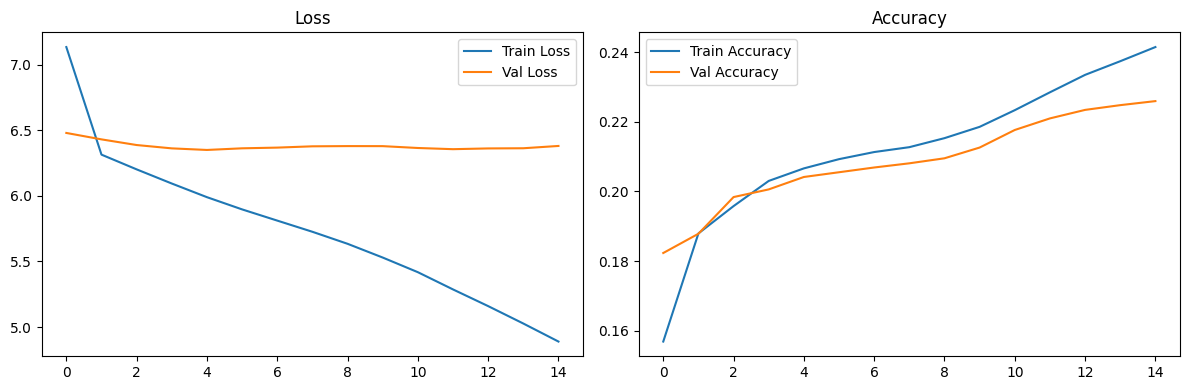

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [11]:
import os
os.makedirs('/content/drive/MyDrive/NLP_Project', exist_ok=True)

model.save('/content/drive/MyDrive/NLP_Project/headline_generation_lstm.keras')
print("Saved!")

Saved!


In [14]:
!rm -rf /content/drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [15]:
import gc
import torch

gc.collect()
torch.cuda.empty_cache()
print("Memory cleared!")

Memory cleared!


# SECTION 5. BART MODEL

In [16]:
from transformers import BartTokenizer, BartForConditionalGeneration
import torch

tokenizer_bart = BartTokenizer.from_pretrained('facebook/bart-base')
bart_model = BartForConditionalGeneration.from_pretrained('facebook/bart-base')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
bart_model = bart_model.to(device)

print(f"BART loaded on: {device}")
print(f"Parameters: {bart_model.num_parameters():,}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/558M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

BART loaded on: cuda
Parameters: 139,420,416


### BART TOKENIZER

In [17]:
# Tokenize data for BART
def tokenize_bart(articles, highlights, max_input=512, max_target=64):
    inputs = tokenizer_bart(
        list(articles),
        max_length=max_input,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )
    targets = tokenizer_bart(
        list(highlights),
        max_length=max_target,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )
    return inputs, targets

# Use cleaned articles and original highlights (not <sos>/<eos> wale)
train_inputs, train_targets = tokenize_bart(
    df['article_clean'].iloc[:4000],
    df['highlights'].iloc[:4000]
)
val_inputs, val_targets = tokenize_bart(
    df['article_clean'].iloc[4000:4500],
    df['highlights'].iloc[4000:4500]
)

print("Train input shape:", train_inputs['input_ids'].shape)
print("Val input shape:", val_inputs['input_ids'].shape)
print("Tokenization done!")

Train input shape: torch.Size([4000, 512])
Val input shape: torch.Size([500, 512])
Tokenization done!


### BART DATASET AND DATALOADER

In [18]:
import torch
from torch.utils.data import Dataset, DataLoader

class HeadlineDataset(Dataset):
    def __init__(self, inputs, targets):
        self.input_ids = inputs['input_ids']
        self.attention_mask = inputs['attention_mask']
        self.labels = targets['input_ids']

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return {
            'input_ids': self.input_ids[idx],
            'attention_mask': self.attention_mask[idx],
            'labels': self.labels[idx]
        }

train_dataset = HeadlineDataset(train_inputs, train_targets)
val_dataset   = HeadlineDataset(val_inputs, val_targets)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)  # 8→4
val_loader   = DataLoader(val_dataset, batch_size=4) 

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")

Train batches: 1000
Val batches:   125


### BART TRAINING

In [19]:
from torch.optim import AdamW


from torch.optim.lr_scheduler import StepLR

optimizer = AdamW(bart_model.parameters(), lr=5e-5)

def train_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0
    for batch in loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        outputs = model(input_ids=input_ids,
                       attention_mask=attention_mask,
                       labels=labels)
        loss = outputs.loss
        total_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    return total_loss / len(loader)

def eval_epoch(model, loader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)

            outputs = model(input_ids=input_ids,
                           attention_mask=attention_mask,
                           labels=labels)
            total_loss += outputs.loss.item()

    return total_loss / len(loader)

# Training loop
EPOCHS = 3
train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    train_loss = train_epoch(bart_model, train_loader, optimizer)
    val_loss   = eval_epoch(bart_model, val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

print("BART Training complete!")

Epoch 1/3 | Train Loss: 2.4780 | Val Loss: 1.9759
Epoch 2/3 | Train Loss: 1.8957 | Val Loss: 1.9758
Epoch 3/3 | Train Loss: 1.5978 | Val Loss: 2.0373
BART Training complete!


In [20]:
bart_model.save_pretrained('/content/drive/MyDrive/NLP_Project/bart_headline')
tokenizer_bart.save_pretrained('/content/drive/MyDrive/NLP_Project/bart_headline')
print("BART saved!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

BART saved!


In [35]:
import gc
import torch

gc.collect()
torch.cuda.empty_cache()
print("Memory cleared!")

Memory cleared!


### PLOT BART

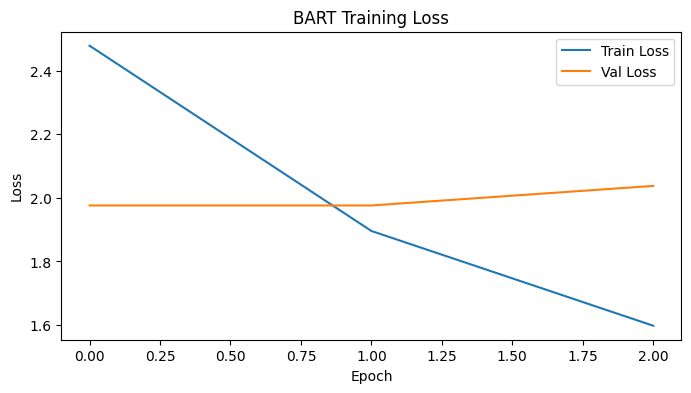

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('BART Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Section 6: T5 + Hybrid Attention

In [22]:
!pip install rouge_score -q

import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import T5Tokenizer, T5ForConditionalGeneration
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
import numpy as np
import gc
import torch
from torch.optim import AdamW
from tqdm import tqdm

# Reuse device from Division 1
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")

  Preparing metadata (setup.py) ... done
Device: cuda


### HYBRID ATTENTION MODULE

In [23]:
class HybridAttention(nn.Module):
    def __init__(self, hidden_dim=512, window_size=4, num_heads=8):
        super(HybridAttention, self).__init__()
        self.hidden_dim  = hidden_dim
        self.window_size = window_size
        self.num_heads   = num_heads

        self.local_q  = nn.Linear(hidden_dim, hidden_dim)
        self.local_k  = nn.Linear(hidden_dim, hidden_dim)
        self.local_v  = nn.Linear(hidden_dim, hidden_dim)

        self.global_q = nn.Linear(hidden_dim, hidden_dim)
        self.global_k = nn.Linear(hidden_dim, hidden_dim)
        self.global_v = nn.Linear(hidden_dim, hidden_dim)

        self.out_proj = nn.Linear(hidden_dim * 2, hidden_dim)
        self.dropout  = nn.Dropout(0.1)
        self.norm     = nn.LayerNorm(hidden_dim)

    def local_attention(self, x):
        B, T, D = x.shape
        W     = self.window_size
        scale = D ** -0.5

        Q = self.local_q(x)
        K = self.local_k(x)
        V = self.local_v(x)

        # Pad along time dimension
        K_pad = F.pad(K.transpose(1, 2), (W, W), mode='constant', value=0).transpose(1, 2)
        V_pad = F.pad(V.transpose(1, 2), (W, W), mode='constant', value=0).transpose(1, 2)

        # Stack shifted windows — safe, no einsum
        win_size = 2 * W + 1
        K_wins = torch.stack([K_pad[:, i:i+T, :] for i in range(win_size)], dim=2)  # (B, T, 2W+1, D)
        V_wins = torch.stack([V_pad[:, i:i+T, :] for i in range(win_size)], dim=2)  # (B, T, 2W+1, D)

        # scores: (B, T, 2W+1)
        scores  = (Q.unsqueeze(2) * K_wins).sum(dim=-1) * scale
        weights = F.softmax(scores, dim=-1)
        weights = self.dropout(weights)

        # output: (B, T, D)
        output = (weights.unsqueeze(-1) * V_wins).sum(dim=2)
        return output

    def global_attention(self, x):
        B, T, D = x.shape
        scale = D ** -0.5

        anchor_idx = [0, T // 2, T - 1]
        anchors    = x[:, anchor_idx, :]

        Q = self.global_q(x)
        K = self.global_k(anchors)
        V = self.global_v(anchors)

        scores  = torch.bmm(Q, K.transpose(1, 2)) * scale
        weights = F.softmax(scores, dim=-1)
        weights = self.dropout(weights)
        output  = torch.bmm(weights, V)
        return output

    def forward(self, encoder_hidden_states):
        residual   = encoder_hidden_states
        local_out  = self.local_attention(encoder_hidden_states)
        global_out = self.global_attention(encoder_hidden_states)
        combined   = torch.cat([local_out, global_out], dim=-1)
        combined   = self.out_proj(combined)
        combined   = self.dropout(combined)
        return self.norm(combined + residual)

print("HybridAttention defined ✓")

HybridAttention defined ✓


### T5 + HYBRID ATTENTION WRAPPER

In [24]:
# ── CELL 2: T5 WRAPPER ──
from transformers import T5Tokenizer, T5ForConditionalGeneration
from transformers.modeling_outputs import BaseModelOutput

class T5WithHybridAttention(nn.Module):
    def __init__(self, model_name='t5-small'):
        super(T5WithHybridAttention, self).__init__()
        self.t5          = T5ForConditionalGeneration.from_pretrained(model_name)
        self.hybrid_attn = HybridAttention(
            hidden_dim  = self.t5.config.d_model,
            window_size = 4,
            num_heads   = 8
        )

    def forward(self, input_ids, attention_mask, labels=None):
        encoder_outputs = self.t5.encoder(
            input_ids      = input_ids,
            attention_mask = attention_mask
        )
        hidden_states  = encoder_outputs.last_hidden_state
        refined_hidden = self.hybrid_attn(hidden_states)

        encoder_out_refined = BaseModelOutput(last_hidden_state=refined_hidden)
        outputs = self.t5(
            attention_mask  = attention_mask,
            encoder_outputs = encoder_out_refined,
            labels          = labels
        )
        return outputs

    def generate_summary(self, input_ids, attention_mask, max_length=64):
        self.eval()
        with torch.no_grad():
            encoder_outputs = self.t5.encoder(
                input_ids      = input_ids,
                attention_mask = attention_mask
            )
            hidden_states  = encoder_outputs.last_hidden_state
            refined_hidden = self.hybrid_attn(hidden_states)

            encoder_out_refined = BaseModelOutput(last_hidden_state=refined_hidden)
            generated = self.t5.generate(
                attention_mask       = attention_mask,
                encoder_outputs      = encoder_out_refined,
                max_length           = max_length,
                num_beams            = 4,
                early_stopping       = True,
                no_repeat_ngram_size = 3
            )
        return generated

# ── Load fresh model ──
import gc
gc.collect()
torch.cuda.empty_cache()

device       = 'cuda' if torch.cuda.is_available() else 'cpu'
tokenizer_t5 = T5Tokenizer.from_pretrained('t5-small')
t5_model     = T5WithHybridAttention('t5-small').to(device)

print(f"Device: {device}")
print(f"Parameters: {sum(p.numel() for p in t5_model.parameters()):,}")
print("T5 + HybridAttention ready ✓")

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Device: cuda
Parameters: 62,608,384
T5 + HybridAttention ready ✓


### TOKENIZATION FOR T5

In [25]:
# ── CELL 3: TOKENIZE + DATALOADERS ──
from torch.utils.data import Dataset, DataLoader

def tokenize_t5(articles, highlights, max_input=128, max_target=64):
    prefixed = ["summarize: " + str(a) for a in articles]
    inputs = tokenizer_t5(
        prefixed,
        max_length     = max_input,
        padding        = 'max_length',
        truncation     = True,
        return_tensors = 'pt'
    )
    targets = tokenizer_t5(
        list(highlights),
        max_length     = max_target,
        padding        = 'max_length',
        truncation     = True,
        return_tensors = 'pt'
    )
    labels = targets['input_ids'].clone()
    labels[labels == tokenizer_t5.pad_token_id] = -100
    return inputs, labels



### DATASET & DATALOADER

In [26]:
class T5HeadlineDataset(Dataset):
    def __init__(self, inputs, labels):
        self.input_ids      = inputs['input_ids']
        self.attention_mask = inputs['attention_mask']
        self.labels         = labels

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return {
            'input_ids':      self.input_ids[idx],
            'attention_mask': self.attention_mask[idx],
            'labels':         self.labels[idx]
        }

t5_train_inputs, t5_train_labels = tokenize_t5(
    df['article_clean'].iloc[:4000],
    df['highlights'].iloc[:4000]
)
t5_val_inputs, t5_val_labels = tokenize_t5(
    df['article_clean'].iloc[4000:4500],
    df['highlights'].iloc[4000:4500]
)

t5_train_dataset = T5HeadlineDataset(t5_train_inputs, t5_train_labels)
t5_val_dataset   = T5HeadlineDataset(t5_val_inputs,   t5_val_labels)

t5_train_loader = DataLoader(t5_train_dataset, batch_size=8, shuffle=True)
t5_val_loader   = DataLoader(t5_val_dataset,   batch_size=8)

print(f"Train batches: {len(t5_train_loader)}")
print(f"Val batches:   {len(t5_val_loader)}")
print("Dataloaders ready ✓")

Train batches: 500
Val batches:   63
Dataloaders ready ✓


### TRAINING LOOP

In [27]:
# ── CELL 4: TRAINING ──
from torch.optim import AdamW
from tqdm import tqdm

def train_epoch_t5(model, loader, optimizer, epoch, total_epochs):
    model.train()
    total_loss = 0
    pbar = tqdm(loader,
                desc=f"Epoch {epoch}/{total_epochs} [Train]",
                bar_format='{l_bar}{bar:30}{r_bar}',
                colour='green')
    for batch in pbar:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss    = outputs.loss
        total_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'avg': f'{total_loss/(pbar.n+1):.4f}'})

    return total_loss / len(loader)

def eval_epoch_t5(model, loader, epoch, total_epochs):
    model.eval()
    total_loss = 0
    pbar = tqdm(loader,
                desc=f"Epoch {epoch}/{total_epochs} [Val]  ",
                bar_format='{l_bar}{bar:30}{r_bar}',
                colour='blue')
    with torch.no_grad():
        for batch in pbar:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            total_loss += outputs.loss.item()
            pbar.set_postfix({'val_loss': f'{total_loss/(pbar.n+1):.4f}'})

    return total_loss / len(loader)

optimizer_t5       = AdamW(t5_model.parameters(), lr=5e-5)
EPOCHS_T5          = 5
t5_train_losses, t5_val_losses = [], []

print("=" * 55)
print("      T5 + Hybrid Attention Training")
print("=" * 55)

for epoch in range(1, EPOCHS_T5 + 1):
    train_loss = train_epoch_t5(t5_model, t5_train_loader, optimizer_t5, epoch, EPOCHS_T5)
    val_loss   = eval_epoch_t5(t5_model, t5_val_loader, epoch, EPOCHS_T5)
    t5_train_losses.append(train_loss)
    t5_val_losses.append(val_loss)
    print(f"\n>>> Epoch {epoch}/{EPOCHS_T5} | Train: {train_loss:.4f} | Val: {val_loss:.4f}\n")

print("=" * 55)
print("Training complete!")

      T5 + Hybrid Attention Training


Epoch 1/5 [Val]  : 100%|██████████████████████████████| 63/63 [00:02<00:00, 25.25it/s, val_loss=5.7295]



>>> Epoch 1/5 | Train: 7.0609 | Val: 5.5476



Epoch 2/5 [Val]  : 100%|██████████████████████████████| 63/63 [00:02<00:00, 24.90it/s, val_loss=5.2746]



>>> Epoch 2/5 | Train: 5.8250 | Val: 5.1071



...


>>> Epoch 3/5 | Train: 5.4378 | Val: 4.9422



Epoch 4/5 [Val]  : 100%|██████████████████████████████| 63/63 [00:02<00:00, 26.42it/s, val_loss=4.8409]



>>> Epoch 4/5 | Train: 5.1742 | Val: 4.6872



Epoch 5/5 [Val]  : 100%|██████████████████████████████| 63/63 [00:02<00:00, 25.80it/s, val_loss=4.5907]


>>> Epoch 5/5 | Train: 4.9228 | Val: 4.4450

Training complete!


### SAVE MODEL

In [28]:
import os
from google.colab import drive

# Remount drive
drive.mount('/content/drive', force_remount=True)

# Create directory if it doesn't exist
os.makedirs('/content/drive/MyDrive/NLP_Project', exist_ok=True)
print("Drive mounted & directory ready ✓")

# ── Save model ──
torch.save(t5_model.state_dict(),
           '/content/drive/MyDrive/NLP_Project/t5_hybrid_attention.pt')
tokenizer_t5.save_pretrained(
           '/content/drive/MyDrive/NLP_Project/t5_hybrid_tokenizer')
print("Model saved ✓")

Mounted at /content/drive
Drive mounted & directory ready ✓
Model saved ✓


### INFERENCE TEST 

In [29]:
def generate_t5_summary(article_text, max_length=64):
    t5_model.eval()
    prefixed = "summarize: " + article_text
    inputs   = tokenizer_t5(
        prefixed,
        return_tensors = 'pt',
        max_length     = 128,
        truncation     = True,
        padding        = 'max_length'
    ).to(device)
    generated = t5_model.generate_summary(
        input_ids      = inputs['input_ids'],
        attention_mask = inputs['attention_mask'],
        max_length     = max_length
    )
    return tokenizer_t5.decode(generated[0], skip_special_tokens=True)

print("\n--- Inference Test ---")
for i in [0, 1, 2]:
    sample  = df['article_clean'].iloc[4500 + i]
    ref     = df['highlights'].iloc[4500 + i]
    summary = generate_t5_summary(sample)
    print(f"\nSample {i+1}")
    print(f"Reference : {ref[:150]}")
    print(f"Generated : {summary}")


--- Inference Test ---

Sample 1
Reference : Bob Slade, 65, had been a crossing supervisor outside the Manadon Vale primary school, Plymouth, for four-and-a-half years .
Plymouth City Council thr
Generated : Bob Slade 65 had been a crossing patrol supervisor in Plymouth devon.

Sample 2
Reference : Xiaomi has launched two new smartphones - the Mi-S2 and Mi-2A .
Both run Android, Google's smartphone software .
Generated : The company has launched two new new smartphones xiaomi Mis2 and Mi2a. The company gaining reputation for being apple of east.

Sample 3
Reference : Andrey Arshavin hits four goals as Arsenal draw 4-4 at Liverpool who go top .
Arshavin opened scoring after 36 minutes and added more on 67, 70 and 90
Generated : Russian Arshavin became the first player to score four goals in a league game at liverpool for 64 years.


### PLOT MODEL

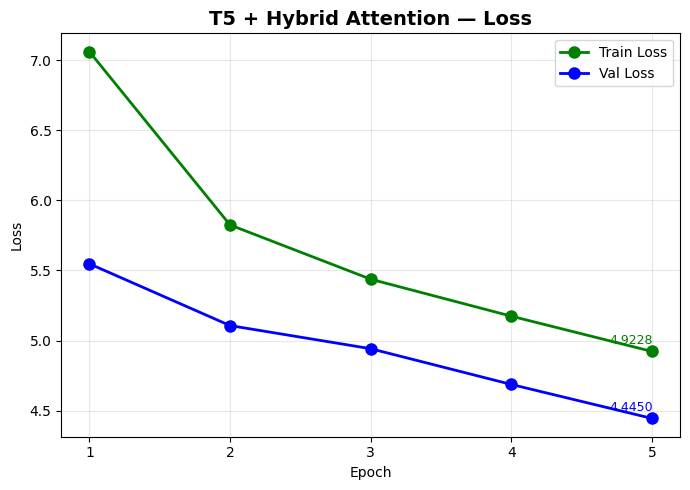

In [30]:
import matplotlib.pyplot as plt

epochs = range(1, EPOCHS_T5 + 1)
plt.figure(figsize=(7, 5))

plt.plot(epochs, t5_train_losses, 'g-o', linewidth=2, markersize=8, label='Train Loss')
plt.plot(epochs, t5_val_losses,   'b-o', linewidth=2, markersize=8, label='Val Loss')

plt.title('T5 + Hybrid Attention — Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(epochs)
plt.legend()
plt.grid(True, alpha=0.3)

plt.annotate(f'{t5_train_losses[-1]:.4f}',
             xy=(EPOCHS_T5, t5_train_losses[-1]),
             xytext=(EPOCHS_T5 - 0.3, t5_train_losses[-1] + 0.05),
             fontsize=9, color='green')
plt.annotate(f'{t5_val_losses[-1]:.4f}',
             xy=(EPOCHS_T5, t5_val_losses[-1]),
             xytext=(EPOCHS_T5 - 0.3, t5_val_losses[-1] + 0.05),
             fontsize=9, color='blue')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/NLP_Project/t5_loss_curve.png', dpi=150)
plt.show()

### MEMORY CLEARENCE

In [31]:
if torch.cuda.is_available():
    allocated = torch.cuda.memory_allocated() / 1024**2
    reserved  = torch.cuda.memory_reserved()  / 1024**2
    print(f"GPU Allocated: {allocated:.1f} MB")
    print(f"GPU Reserved:  {reserved:.1f} MB")

GPU Allocated: 3126.7 MB
GPU Reserved:  4016.0 MB


In [32]:
# ── PROPER MEMORY CLEANUP BEFORE COMPARISON ──
import gc
import torch
import tensorflow as tf

# ── 1. Clear Keras/TensorFlow (BiLSTM) ──
tf.keras.backend.clear_session()
print("Keras session cleared ✓")

# ── 2. Delete BART training model (loaded in Division 1) ──
try:
    del bart_model
    print("BART training model deleted ✓")
except NameError:
    print("BART already cleared ✓")

# ── 3. Delete any leftover optimizer states ──
try:
    del optimizer_t5
    print("T5 optimizer deleted ✓")
except NameError:
    pass

# ── 4. Python garbage collection ──
gc.collect()

# ── 5. PyTorch GPU cache clear ──
torch.cuda.empty_cache()
torch.cuda.synchronize()

# ── 6. Check memory after cleanup ──
if torch.cuda.is_available():
    allocated = torch.cuda.memory_allocated() / 1024**2
    reserved  = torch.cuda.memory_reserved()  / 1024**2
    total     = torch.cuda.get_device_properties(0).total_memory / 1024**2
    free      = total - reserved

    print(f"\n{'='*40}")
    print(f"  GPU Memory Report")
    print(f"{'='*40}")
    print(f"  Total GPU RAM : {total:.1f} MB")
    print(f"  Allocated     : {allocated:.1f} MB")
    print(f"  Reserved      : {reserved:.1f} MB")
    print(f"  Free (approx) : {free:.1f} MB")
    print(f"{'='*40}")

    if free < 1000:
        print("WARNING: Less than 1GB free — consider Runtime > Restart")
    else:
        print("Enough memory for comparison analysis!")

Keras session cleared ✓
BART training model deleted ✓
T5 optimizer deleted ✓

  GPU Memory Report
  Total GPU RAM : 14912.7 MB
  Allocated     : 2647.6 MB
  Reserved      : 3222.0 MB
  Free (approx) : 11690.7 MB
Enough memory for comparison analysis!


# SECTION 7: COMPARISON ANALYSIS — All 3 Models on Test Set

In [33]:
import time
import numpy as np
import torch
from rouge_score import rouge_scorer
from tqdm import tqdm
from tensorflow.keras.preprocessing.sequence import pad_sequences
from transformers import BartTokenizer, BartForConditionalGeneration

In [34]:
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# ── Test samples ──
N_TEST           = 100
test_articles    = df['article_clean'].iloc[4500:4500+N_TEST].tolist()
test_highlights  = df['highlights'].iloc[4500:4500+N_TEST].tolist()

print(f"Evaluating on {N_TEST} test samples")
print(f"Device: {device}")
print("=" * 60)

Evaluating on 100 test samples
Device: cuda


### MODEL 1: Seq2Seq BiLSTM

In [ ]:
import os

# ── Check all possible paths ──────────────────────────────────
paths_to_check = [
    '/content/drive/MyDrive/NLP_Project/headline_generation_lstm.keras',
    '/content/drive/MyDrive/headline_generation_lstm.keras',
    '/content/drive/MyDrive/NLP_Project/headline_generation_lstm.keras',
    '/content/NLP_Project/headline_generation_lstm.keras',
    '/content/headline_generation_lstm.keras',
]

print("🔍 Checking all possible LSTM paths...\n")
found = False
for p in paths_to_check:
    exists = os.path.exists(p)
    status = "✅ FOUND" if exists else "❌ NOT FOUND"
    print(f"{status} → {p}")
    if exists:
        size = os.path.getsize(p) / (1024*1024)
        print(f"         📦 File size: {size:.1f} MB")
        found = True

🔍 Checking all possible LSTM paths...

❌ NOT FOUND → /content/drive/MyDrive/NLP_Project/headline_generation_lstm.keras
✅ FOUND → /content/drive/MyDrive/headline_generation_lstm.keras
         📦 File size: 320.3 MB
❌ NOT FOUND → /content/drive/MyDrive/NLP_Project/headline_generation_lstm.keras
❌ NOT FOUND → /content/NLP_Project/headline_generation_lstm.keras
❌ NOT FOUND → /content/headline_generation_lstm.keras


In [46]:
print("\n📌 Model 1: Seq2Seq BiLSTM")

# Reload saved LSTM model
from tensorflow.keras.models import load_model

class BahdanauAttention(tf.keras.layers.Layer):
    def __init__(self, units, **kwargs):
        super(BahdanauAttention, self).__init__(**kwargs)
        self.units = units
        self.W1 = tf.keras.layers.Dense(units)
        self.W2 = tf.keras.layers.Dense(units)
        self.V  = tf.keras.layers.Dense(1)

    def call(self, inputs):
        encoder_output, decoder_hidden = inputs
        decoder_hidden = tf.expand_dims(decoder_hidden, 1)
        score = self.V(tf.nn.tanh(self.W1(encoder_output) + self.W2(decoder_hidden)))
        attention_weights = tf.nn.softmax(score, axis=1)
        context_vector = attention_weights * encoder_output
        context_vector = tf.reduce_sum(context_vector, axis=1)
        return context_vector

    def get_config(self):
        config = super().get_config()
        config.update({'units': self.units})
        return config

import tensorflow as tf
lstm_model = load_model(
    '/content/drive/MyDrive/headline_generation_lstm.keras',
    custom_objects={'BahdanauAttention': BahdanauAttention}
)
print("BiLSTM loaded ✓")



📌 Model 1: Seq2Seq BiLSTM


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'bahdanau_attention', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


BiLSTM loaded ✓


In [47]:
def generate_lstm_summary(article_text, max_len=50):
    seq = art_tokenizer.texts_to_sequences([article_text])
    seq = pad_sequences(seq, maxlen=MAX_ARTICLE_LEN, padding='post', truncating='post')

    sos_idx = hl_tokenizer.word_index.get('<sos>', 1)
    eos_idx = hl_tokenizer.word_index.get('<eos>', 2)

    target_seq    = np.zeros((1, MAX_HIGHLIGHT_LEN))
    target_seq[0, 0] = sos_idx
    result_tokens = []

    for i in range(1, max_len):
        preds     = lstm_model.predict([seq, target_seq], verbose=0)
        token_idx = np.argmax(preds[0, i-1, :])

        if token_idx == eos_idx or token_idx == 0:
            break

        word = hl_tokenizer.index_word.get(token_idx, '')
        if word and word not in ['<sos>', '<eos>', '<OOV>']:
            result_tokens.append(word)

        target_seq[0, i] = token_idx

    return ' '.join(result_tokens)

lstm_preds = []
lstm_times = []

pbar = tqdm(range(N_TEST), desc="BiLSTM inference ",
            bar_format='{l_bar}{bar:30}{r_bar}', colour='red')
for i in pbar:
    start = time.time()
    pred  = generate_lstm_summary(test_articles[i])
    lstm_times.append(time.time() - start)
    lstm_preds.append(pred)
    pbar.set_postfix({'sample': i+1})

lstm_scores = {'rouge1': [], 'rouge2': [], 'rougeL': []}
for pred, ref in zip(lstm_preds, test_highlights):
    s = scorer.score(ref, pred)
    lstm_scores['rouge1'].append(s['rouge1'].fmeasure)
    lstm_scores['rouge2'].append(s['rouge2'].fmeasure)
    lstm_scores['rougeL'].append(s['rougeL'].fmeasure)

lstm_results = {k: np.mean(v) for k, v in lstm_scores.items()}
lstm_results['avg_time'] = np.mean(lstm_times)
lstm_results['params']   = 27_984_161

print(f"  ROUGE-1: {lstm_results['rouge1']:.4f}")
print(f"  ROUGE-2: {lstm_results['rouge2']:.4f}")
print(f"  ROUGE-L: {lstm_results['rougeL']:.4f}")
print(f"  Avg time: {lstm_results['avg_time']:.3f}s")

# Clear LSTM from memory
del lstm_model
gc.collect()
print("BiLSTM cleared from memory ✓")


BiLSTM inference : 100%|██████████████████████████████| 100/100 [01:10<00:00,  1.42it/s, sample=100]


  ROUGE-1: 0.0501
  ROUGE-2: 0.0000
  ROUGE-L: 0.0453
  Avg time: 0.700s
BiLSTM cleared from memory ✓


### MODEL 2: BART

In [40]:
import os
print(os.path.exists('/content/drive/MyDrive/NLP_Project/bart_headline'))

True


In [41]:
print("\n📌 Model 2: BART")

bart_model_eval     = BartForConditionalGeneration.from_pretrained(
    '/content/drive/MyDrive/NLP_Project/bart_headline'
).to(device)
tokenizer_bart_eval = BartTokenizer.from_pretrained(
    '/content/drive/MyDrive/NLP_Project/bart_headline'
)
bart_model_eval.eval()
print("BART loaded ✓")

def generate_bart_summary(article_text, max_length=64):
    inputs = tokenizer_bart_eval(
        article_text,
        return_tensors = 'pt',
        max_length     = 512,
        truncation     = True,
        padding        = 'max_length'
    ).to(device)
    with torch.no_grad():
        output = bart_model_eval.generate(
            input_ids            = inputs['input_ids'],
            attention_mask       = inputs['attention_mask'],
            max_length           = max_length,
            num_beams            = 4,
            early_stopping       = True,
            no_repeat_ngram_size = 3
        )
    return tokenizer_bart_eval.decode(output[0], skip_special_tokens=True)

bart_preds = []
bart_times = []

pbar = tqdm(range(N_TEST), desc="BART inference   ",
            bar_format='{l_bar}{bar:30}{r_bar}', colour='yellow')
for i in pbar:
    start = time.time()
    pred  = generate_bart_summary(test_articles[i])
    bart_times.append(time.time() - start)
    bart_preds.append(pred)
    pbar.set_postfix({'sample': i+1})

bart_scores = {'rouge1': [], 'rouge2': [], 'rougeL': []}
for pred, ref in zip(bart_preds, test_highlights):
    s = scorer.score(ref, pred)
    bart_scores['rouge1'].append(s['rouge1'].fmeasure)
    bart_scores['rouge2'].append(s['rouge2'].fmeasure)
    bart_scores['rougeL'].append(s['rougeL'].fmeasure)

bart_results = {k: np.mean(v) for k, v in bart_scores.items()}
bart_results['avg_time'] = np.mean(bart_times)
bart_results['params']   = 139_420_416

print(f"  ROUGE-1: {bart_results['rouge1']:.4f}")
print(f"  ROUGE-2: {bart_results['rouge2']:.4f}")
print(f"  ROUGE-L: {bart_results['rougeL']:.4f}")
print(f"  Avg time: {bart_results['avg_time']:.3f}s")

# Clear BART from memory
del bart_model_eval
gc.collect()
torch.cuda.empty_cache()
print("BART cleared from memory ✓")


📌 Model 2: BART


Loading weights:   0%|          | 0/260 [00:00<?, ?it/s]

BART loaded ✓


BART inference   : 100%|██████████████████████████████| 100/100 [01:09<00:00,  1.44it/s, sample=100]


  ROUGE-1: 0.3689
  ROUGE-2: 0.1432
  ROUGE-L: 0.2471
  Avg time: 0.691s
BART cleared from memory ✓


### MODEL 3: T5 + Hybrid Attention

In [42]:
print("\n📌 Model 3: T5 + Hybrid Attention")

t5_model.eval()

def generate_t5_summary_eval(article_text, max_length=64):
    prefixed = "summarize: " + article_text
    inputs   = tokenizer_t5(
        prefixed,
        return_tensors = 'pt',
        max_length     = 128,
        truncation     = True,
        padding        = 'max_length'
    ).to(device)
    generated = t5_model.generate_summary(
        input_ids      = inputs['input_ids'],
        attention_mask = inputs['attention_mask'],
        max_length     = max_length
    )
    return tokenizer_t5.decode(generated[0], skip_special_tokens=True)

t5_preds = []
t5_times = []

pbar = tqdm(range(N_TEST), desc="T5 inference     ",
            bar_format='{l_bar}{bar:30}{r_bar}', colour='green')
for i in pbar:
    start = time.time()
    pred  = generate_t5_summary_eval(test_articles[i])
    t5_times.append(time.time() - start)
    t5_preds.append(pred)
    pbar.set_postfix({'sample': i+1})

t5_scores = {'rouge1': [], 'rouge2': [], 'rougeL': []}
for pred, ref in zip(t5_preds, test_highlights):
    s = scorer.score(ref, pred)
    t5_scores['rouge1'].append(s['rouge1'].fmeasure)
    t5_scores['rouge2'].append(s['rouge2'].fmeasure)
    t5_scores['rougeL'].append(s['rougeL'].fmeasure)

t5_results = {k: np.mean(v) for k, v in t5_scores.items()}
t5_results['avg_time'] = np.mean(t5_times)
t5_results['params']   = sum(p.numel() for p in t5_model.parameters())

print(f"  ROUGE-1: {t5_results['rouge1']:.4f}")
print(f"  ROUGE-2: {t5_results['rouge2']:.4f}")
print(f"  ROUGE-L: {t5_results['rougeL']:.4f}")
print(f"  Avg time: {t5_results['avg_time']:.3f}s")



📌 Model 3: T5 + Hybrid Attention


T5 inference     : 100%|██████████████████████████████| 100/100 [00:55<00:00,  1.79it/s, sample=100]

  ROUGE-1: 0.2368
  ROUGE-2: 0.0827
  ROUGE-L: 0.1827
  Avg time: 0.555s


### FINAL RESULT

In [49]:
print("\n")
print("=" * 65)
print("              FINAL COMPARISON RESULTS")
print("=" * 65)
print(f"{'Metric':<22} {'BiLSTM':>12} {'BART':>12} {'T5+Hybrid':>12}")
print("-" * 65)
print(f"{'ROUGE-1':<22} {lstm_results['rouge1']:>12.4f} {bart_results['rouge1']:>12.4f} {t5_results['rouge1']:>12.4f}")
print(f"{'ROUGE-2':<22} {lstm_results['rouge2']:>12.4f} {bart_results['rouge2']:>12.4f} {t5_results['rouge2']:>12.4f}")
print(f"{'ROUGE-L':<22} {lstm_results['rougeL']:>12.4f} {bart_results['rougeL']:>12.4f} {t5_results['rougeL']:>12.4f}")
print(f"{'Avg Infer Time (s)':<22} {lstm_results['avg_time']:>12.3f} {bart_results['avg_time']:>12.3f} {t5_results['avg_time']:>12.3f}")
print(f"{'Parameters':<22} {lstm_results['params']:>12,} {bart_results['params']:>12,} {t5_results['params']:>12,}")
print("=" * 65)

# ── Save results for visualization ──
all_results = {
    'BiLSTM'   : lstm_results,
    'BART'     : bart_results,
    'T5+Hybrid': t5_results
}




              FINAL COMPARISON RESULTS
Metric                       BiLSTM         BART    T5+Hybrid
-----------------------------------------------------------------
ROUGE-1                      0.0501       0.3689       0.2368
ROUGE-2                      0.0000       0.1432       0.0827
ROUGE-L                      0.0453       0.2471       0.1827
Avg Infer Time (s)            0.700        0.691        0.555
Parameters               27,984,161  139,420,416   62,608,384


# SECTION 8: VISUALIZATIONS

In [50]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os

os.makedirs('/content/drive/MyDrive/NLP_Project/plots', exist_ok=True)

# ── Color palette ──
COLORS = {
    'BiLSTM'    : '#e74c3c',
    'BART'      : '#f39c12',
    'T5+Hybrid' : '#27ae60'
}
models     = ['BiLSTM', 'BART', 'T5+Hybrid']
model_cols = [COLORS[m] for m in models]


### Training Loss Curves — All 3 Models

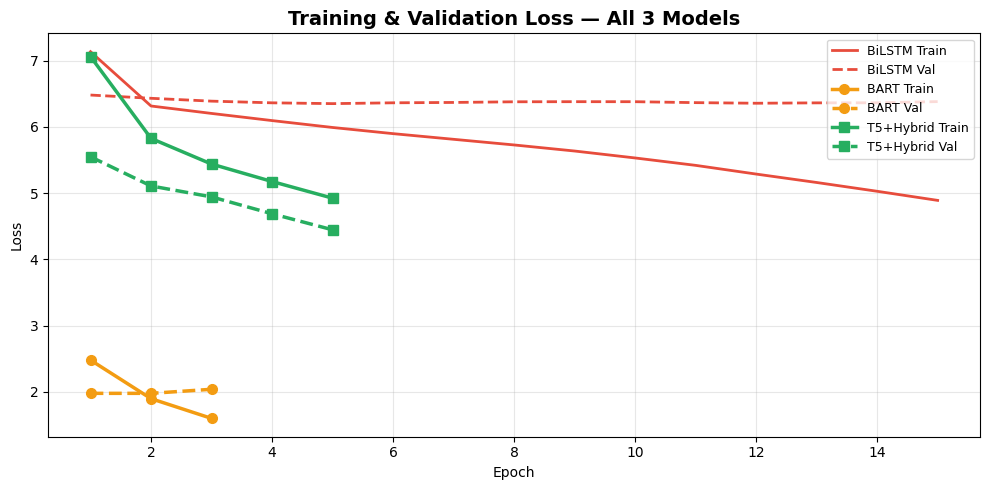

Plot 1 saved ✓


In [51]:
fig, ax = plt.subplots(figsize=(10, 5))

# BiLSTM (from Division 1 history)
lstm_epochs      = range(1, len(history.history['loss']) + 1)
lstm_train_loss  = history.history['loss']
lstm_val_loss    = history.history['val_loss']

ax.plot(lstm_epochs, lstm_train_loss, color='#e74c3c', linestyle='-',
        linewidth=2, label='BiLSTM Train')
ax.plot(lstm_epochs, lstm_val_loss,   color='#e74c3c', linestyle='--',
        linewidth=2, label='BiLSTM Val')

# BART
bart_epochs = range(1, len(train_losses) + 1)
ax.plot(bart_epochs, train_losses, color='#f39c12', linestyle='-',
        linewidth=2.5, marker='o', markersize=7, label='BART Train')
ax.plot(bart_epochs, val_losses,   color='#f39c12', linestyle='--',
        linewidth=2.5, marker='o', markersize=7, label='BART Val')

# T5 + Hybrid
t5_epochs = range(1, len(t5_train_losses) + 1)
ax.plot(t5_epochs, t5_train_losses, color='#27ae60', linestyle='-',
        linewidth=2.5, marker='s', markersize=7, label='T5+Hybrid Train')
ax.plot(t5_epochs, t5_val_losses,   color='#27ae60', linestyle='--',
        linewidth=2.5, marker='s', markersize=7, label='T5+Hybrid Val')

ax.set_title('Training & Validation Loss — All 3 Models', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/NLP_Project/plots/plot1_loss_curves.png', dpi=150)
plt.show()
print("Plot 1 saved ✓")

### ROUGE Score Bar Chart — Grouped

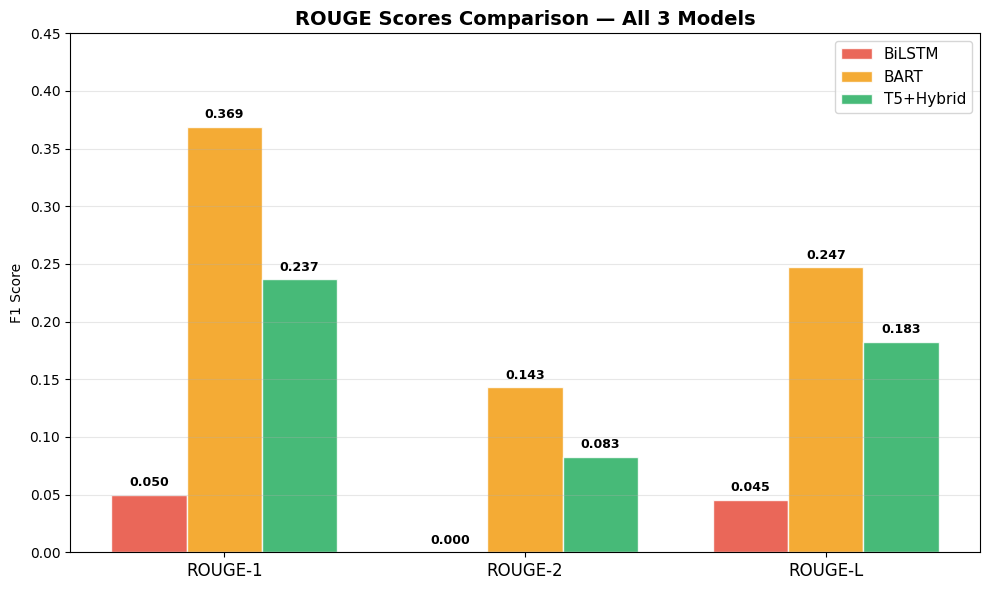

Plot 2 saved ✓


In [52]:
fig, ax = plt.subplots(figsize=(10, 6))

metrics     = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']
metric_keys = ['rouge1',  'rouge2',  'rougeL']

bilstm_scores = [lstm_results[k] for k in metric_keys]
bart_scores_v = [bart_results[k] for k in metric_keys]
t5_scores_v   = [t5_results[k]   for k in metric_keys]

x     = np.arange(len(metrics))
width = 0.25

bars1 = ax.bar(x - width,     bilstm_scores, width, label='BiLSTM',
               color=COLORS['BiLSTM'],     alpha=0.85, edgecolor='white')
bars2 = ax.bar(x,             bart_scores_v, width, label='BART',
               color=COLORS['BART'],       alpha=0.85, edgecolor='white')
bars3 = ax.bar(x + width,     t5_scores_v,   width, label='T5+Hybrid',
               color=COLORS['T5+Hybrid'],  alpha=0.85, edgecolor='white')

# Value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, h),
                    xytext=(0, 4), textcoords='offset points',
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('ROUGE Scores Comparison — All 3 Models', fontsize=14, fontweight='bold')
ax.set_ylabel('F1 Score')
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0, 0.45)
ax.legend(fontsize=11)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/NLP_Project/plots/plot2_rouge_bars.png', dpi=150)
plt.show()
print("Plot 2 saved ✓")

### Hybrid Attention Heatmap

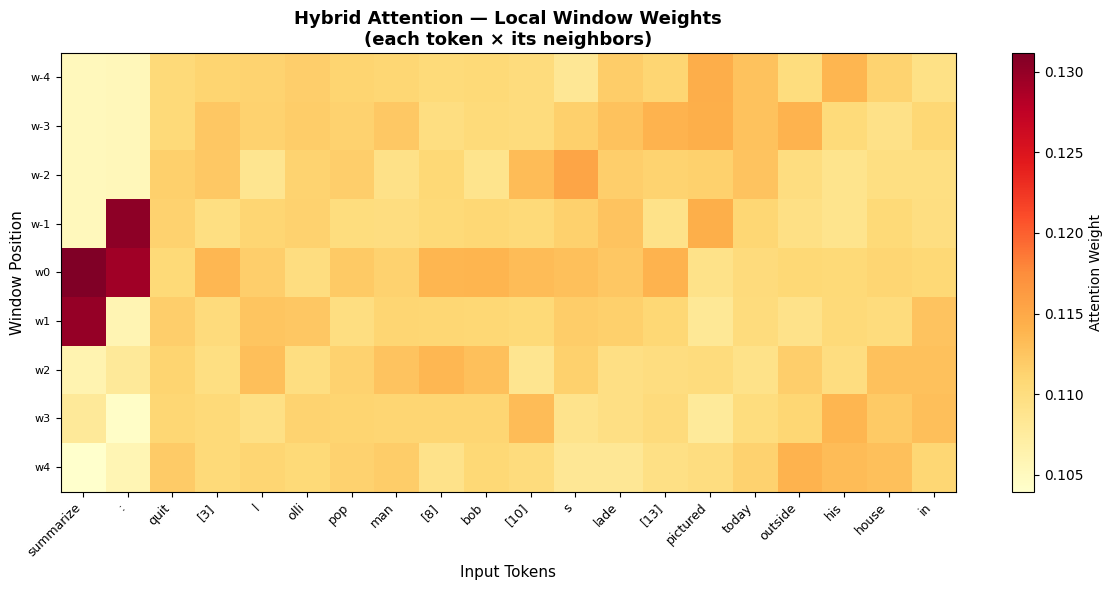

Plot 3 saved ✓


In [53]:
import torch
import torch.nn.functional as F

def get_attention_weights(article_text, n_tokens=20):
    """Extract local attention weights from HybridAttention for visualization"""
    t5_model.eval()
    prefixed = "summarize: " + article_text
    inputs   = tokenizer_t5(
        prefixed,
        return_tensors = 'pt',
        max_length     = 128,
        truncation     = True,
        padding        = 'max_length'
    ).to(device)

    with torch.no_grad():
        encoder_outputs = t5_model.t5.encoder(
            input_ids      = inputs['input_ids'],
            attention_mask = inputs['attention_mask']
        )
        hidden = encoder_outputs.last_hidden_state  # (1, T, 512)

        # Run local attention manually to extract weights
        W     = t5_model.hybrid_attn.window_size
        x     = hidden
        B, T, D = x.shape
        scale = D ** -0.5

        Q = t5_model.hybrid_attn.local_q(x)
        K = t5_model.hybrid_attn.local_k(x)

        K_pad = F.pad(K.transpose(1,2), (W, W), value=0).transpose(1,2)
        win_size = 2 * W + 1
        K_wins = torch.stack([K_pad[:, i:i+T, :] for i in range(win_size)], dim=2)
        scores  = (Q.unsqueeze(2) * K_wins).sum(dim=-1) * scale
        weights = F.softmax(scores, dim=-1)  # (1, T, 2W+1)

    # Return weights for first n_tokens
    w = weights[0, :n_tokens, :].cpu().numpy()

    # Token labels
    token_ids = inputs['input_ids'][0, :n_tokens].cpu().tolist()
    tokens    = [tokenizer_t5.decode([t]).strip() for t in token_ids]
    tokens    = [t if t else f'[{i}]' for i, t in enumerate(tokens)]

    return w, tokens

# Use first test article
sample_article = test_articles[0]
attn_weights, tokens = get_attention_weights(sample_article, n_tokens=20)

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(attn_weights.T, aspect='auto', cmap='YlOrRd')

ax.set_xticks(range(len(tokens)))
ax.set_xticklabels(tokens, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(attn_weights.shape[1]))
ax.set_yticklabels([f'w{i-4}' for i in range(attn_weights.shape[1])], fontsize=8)

ax.set_title('Hybrid Attention — Local Window Weights\n(each token × its neighbors)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Input Tokens', fontsize=11)
ax.set_ylabel('Window Position', fontsize=11)
plt.colorbar(im, ax=ax, label='Attention Weight')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/NLP_Project/plots/plot3_attention_heatmap.png', dpi=150)
plt.show()
print("Plot 3 saved ✓")

### Article Length vs ROUGE-L (Scatter)

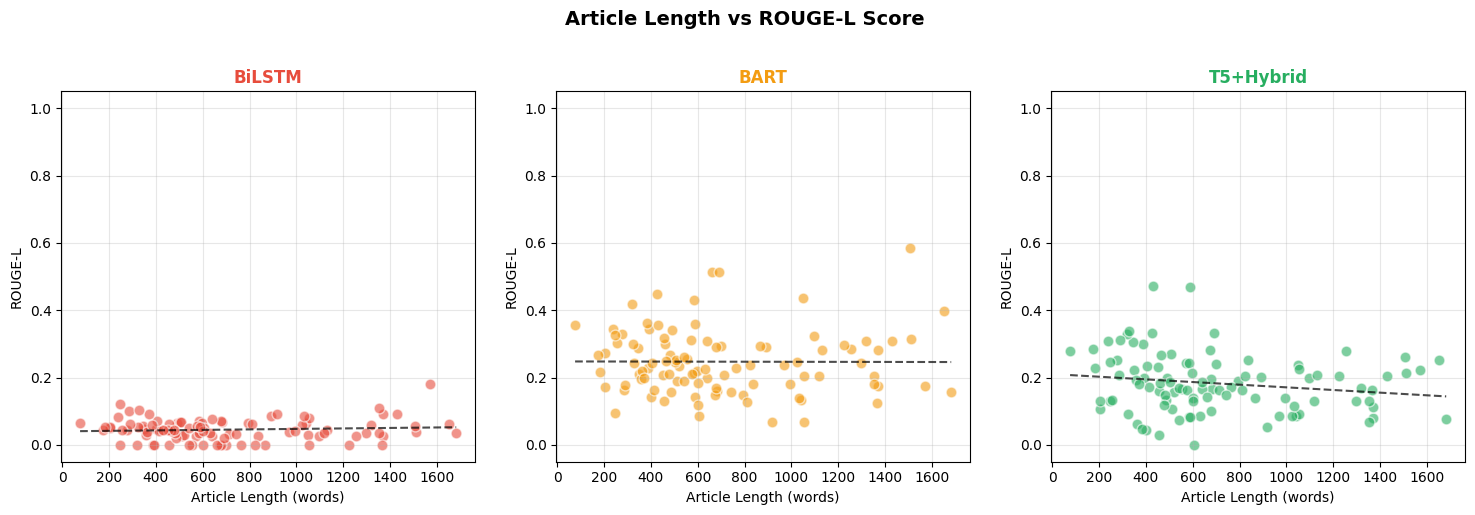

Plot 4 saved ✓


In [54]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

article_lens = [len(a.split()) for a in test_articles]

plot_data = [
    ('BiLSTM',    lstm_preds,  COLORS['BiLSTM']),
    ('BART',      bart_preds,  COLORS['BART']),
    ('T5+Hybrid', t5_preds,    COLORS['T5+Hybrid'])
]

for ax, (name, preds, color) in zip(axes, plot_data):
    rougeL_per_sample = []
    for pred, ref in zip(preds, test_highlights):
        s = scorer.score(ref, pred)
        rougeL_per_sample.append(s['rougeL'].fmeasure)

    ax.scatter(article_lens, rougeL_per_sample,
               alpha=0.6, color=color, edgecolors='white', s=60)

    # Trend line
    z   = np.polyfit(article_lens, rougeL_per_sample, 1)
    p   = np.poly1d(z)
    xs  = np.linspace(min(article_lens), max(article_lens), 100)
    ax.plot(xs, p(xs), color='black', linestyle='--', linewidth=1.5, alpha=0.7)

    ax.set_title(f'{name}', fontsize=12, fontweight='bold', color=color)
    ax.set_xlabel('Article Length (words)')
    ax.set_ylabel('ROUGE-L')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.05, 1.05)

fig.suptitle('Article Length vs ROUGE-L Score', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/NLP_Project/plots/plot4_length_vs_rouge.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot 4 saved ✓")

### Qualitative Examples Table

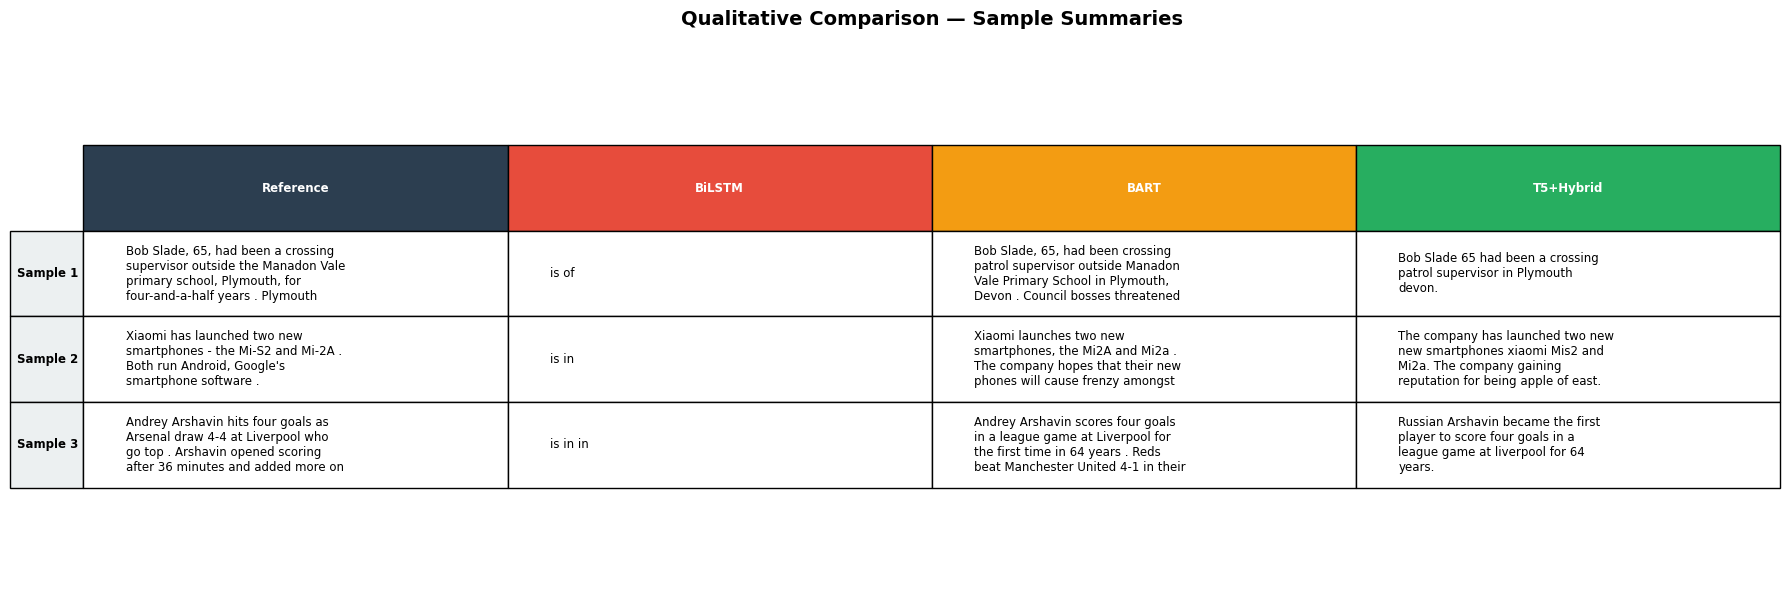

Plot 5 saved ✓


In [55]:
fig, ax = plt.subplots(figsize=(18, 6))
ax.axis('off')

# Pick 3 interesting samples
sample_ids = [0, 1, 2]

col_labels  = ['Reference', 'BiLSTM', 'BART', 'T5+Hybrid']
row_labels  = [f'Sample {i+1}' for i in range(3)]

def wrap(text, width=35):
    """Simple word wrap"""
    words, lines, line = text.split(), [], []
    for w in words:
        if sum(len(x)+1 for x in line) + len(w) > width:
            lines.append(' '.join(line))
            line = [w]
        else:
            line.append(w)
    if line:
        lines.append(' '.join(line))
    return '\n'.join(lines[:4])   # max 4 lines

cell_data = []
for i in sample_ids:
    cell_data.append([
        wrap(test_highlights[i]),
        wrap(lstm_preds[i]  if lstm_preds[i]  else '(empty)'),
        wrap(bart_preds[i]  if bart_preds[i]  else '(empty)'),
        wrap(t5_preds[i]    if t5_preds[i]    else '(empty)')
    ])

table = ax.table(
    cellText    = cell_data,
    rowLabels   = row_labels,
    colLabels   = col_labels,
    cellLoc     = 'left',
    loc         = 'center'
)
table.auto_set_font_size(False)
table.set_fontsize(8.5)
table.scale(1, 4.5)

# Header color
for j, color in enumerate(['#2c3e50', COLORS['BiLSTM'], COLORS['BART'], COLORS['T5+Hybrid']]):
    table[0, j].set_facecolor(color)
    table[0, j].set_text_props(color='white', fontweight='bold')

# Row label color
for i in range(1, 4):
    table[i, -1].set_facecolor('#ecf0f1')
    table[i, -1].set_text_props(fontweight='bold')

ax.set_title('Qualitative Comparison — Sample Summaries',
             fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/NLP_Project/plots/plot5_qualitative_table.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot 5 saved ✓")

### Model Size vs Performance — Bubble Chart

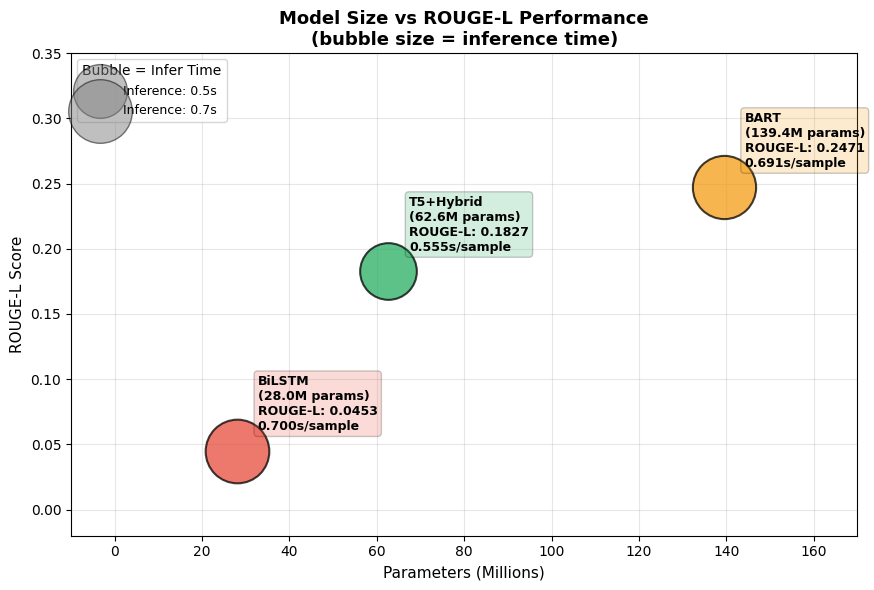

Plot 6 saved ✓


In [56]:
fig, ax = plt.subplots(figsize=(9, 6))

params    = [lstm_results['params'], bart_results['params'], t5_results['params']]
rougeL    = [lstm_results['rougeL'], bart_results['rougeL'], t5_results['rougeL']]
inf_times = [lstm_results['avg_time'], bart_results['avg_time'], t5_results['avg_time']]

# Bubble size = inference time scaled
bubble_sizes = [t * 3000 for t in inf_times]

for i, (name, p, r, b, color) in enumerate(
        zip(models, params, rougeL, bubble_sizes, model_cols)):

    ax.scatter(p / 1e6, r, s=b, color=color, alpha=0.75,
               edgecolors='black', linewidth=1.5, zorder=3)
    ax.annotate(
        f'{name}\n({p/1e6:.1f}M params)\nROUGE-L: {r:.4f}\n{inf_times[i]:.3f}s/sample',
        xy        = (p / 1e6, r),
        xytext    = (15, 15),
        textcoords= 'offset points',
        fontsize  = 9,
        fontweight= 'bold',
        bbox      = dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.2)
    )

ax.set_title('Model Size vs ROUGE-L Performance\n(bubble size = inference time)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Parameters (Millions)', fontsize=11)
ax.set_ylabel('ROUGE-L Score',         fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(-10, 170)
ax.set_ylim(-0.02, 0.35)

# Legend for bubble size
for t, label in [(0.5, '0.5s'), (0.7, '0.7s')]:
    ax.scatter([], [], s=t*3000, color='gray', alpha=0.5,
               edgecolors='black', label=f'Inference: {label}')
ax.legend(title='Bubble = Infer Time', fontsize=9, loc='upper left')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/NLP_Project/plots/plot6_bubble_chart.png', dpi=150)
plt.show()
print("Plot 6 saved ✓")